# **Визуализация данных**

Лабораторная работа  посвящена работе с библиотеками matplotlib и seaborn, позволяющими организовать построение графиков для имеющихся данных.

Рекомендуется выполнять лабораторную работу в Google Colab с использованием браузера. Если на вашем компьютере установлена Anaconda, вы можете скачать задание и выполнять его с использованием Anaconda.



В самом начале работы следует подключить нужные нам библиотеки

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

sns.set_theme(style="whitegrid")

Для выполнения последующих заданий в Google Colab потребуется подключить работу с гугл-диском, запустив следующую ячейку. (https://colab.research.google.com/drive/1DOwvT_j7OIkjZoNL4LwbXxDwmYUn0TLm?usp=sharing).

**Внимание! Если вы выполняете работу в Anaconda, следующую ячейку запускать не нужно!**

In [3]:
# from google.colab import drive
# drive.mount('/content/drive')

Перед выполнением следующих заданий вам нужно загрузить на свой гугл-диск файлы `pogoda.csv`, `tips.csv` и `Video_Games_Sales_as_at_22_Dec_2016.csv`. Файлы прикреплены к заданию.

**Если вы работаете в Anaconda, файлы нужно скачать на компьютер и поместить в папку, из которой вам будет удобно с ними работать.**

**Задание 1**  Загрузите набор данных `pogoda.csv` и для каждого параметра постройте график. Требования:
 - Цвет, стиль, толщина линии у графиков не должны повторяться.
 - Каждый график должен быть в своей системе координат, как показано на рисунке 1.
 - Добавьте названия, подписи осей и легенду.

**Примечание**: обратите внимание, что в таблице столбцы разделены символом табуляции. Для открытия необходимо использовать параметр `sep = '\t'`.


Рисунок 1 - Образец оформления графиков.  
  
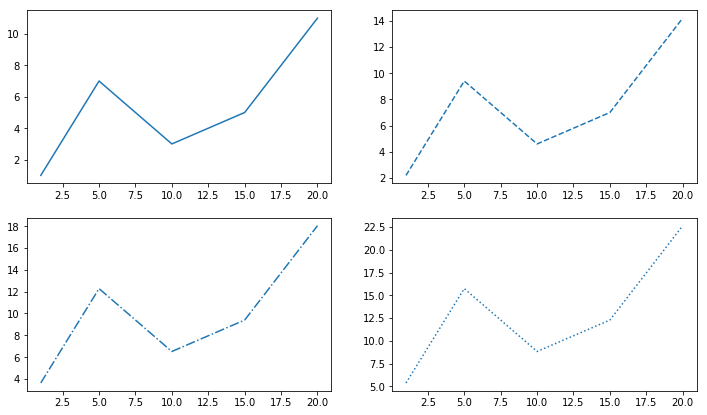

In [4]:
pogoda = pd.read_csv('pogoda.csv', sep='\t')
pogoda.head()

,day,temp,atmosphere_pressure,air_humidity,wind_speed
0,1.0,13.0,747.0,90.0,3.4
1,2.0,9.0,752.0,88.0,3.2
2,3.0,8.0,752.0,92.0,2.9
3,4.0,8.0,749.0,91.0,3.7
4,5.0,6.0,753.0,86.0,4.5


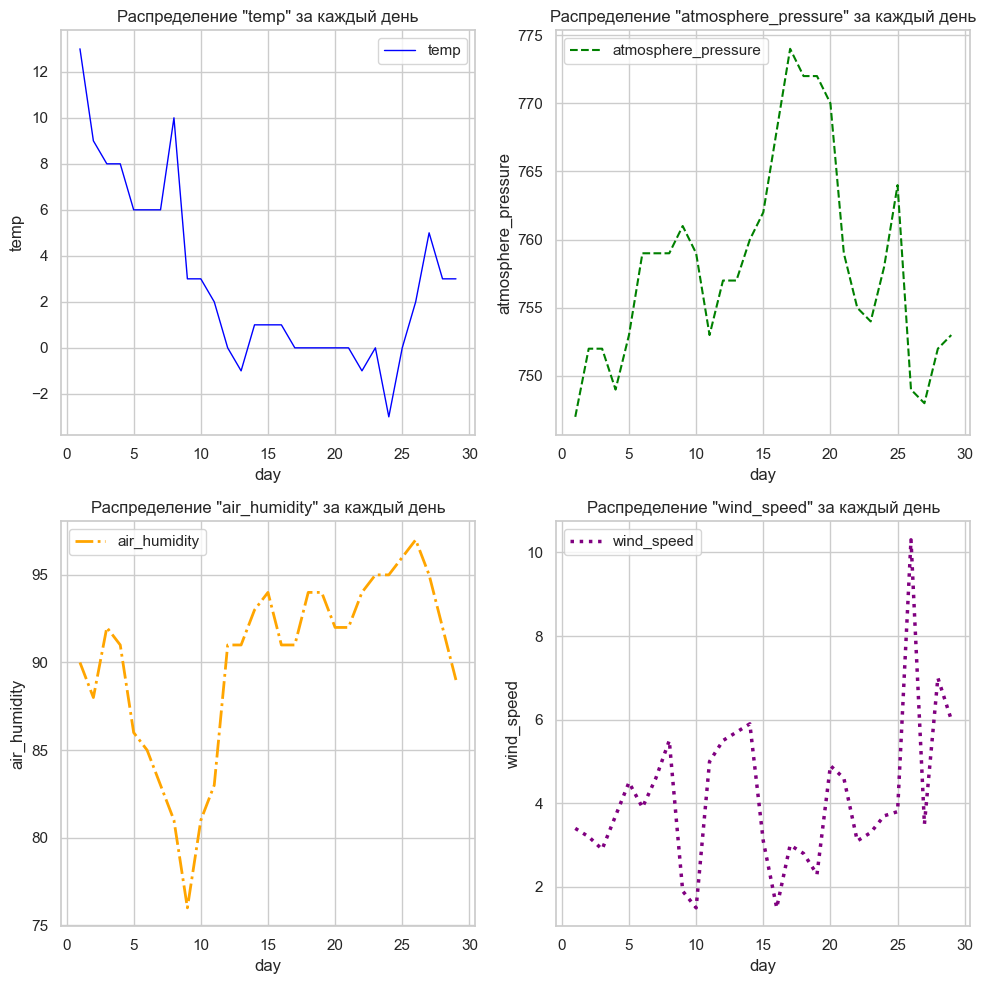

In [5]:
cols = ['temp', 'atmosphere_pressure', 'air_humidity', 'wind_speed']

colors = ['blue', 'green', 'orange', 'purple']
linestyles = ['-', '--', '-.', ':']
widths = [1.0, 1.5, 2.0, 2.5]

fig, ax = plt.subplots(2, 2, figsize=(10, 10))
ax = ax.flatten()

for i, col in enumerate(cols):
    sns.lineplot(
        data=pogoda,
        x='day',
        y=col,
        ax=ax[i],
        color=colors[i],
        linestyle=linestyles[i],
        linewidth=widths[i],
        label=col)
    ax[i].set_title(f'Распределение "{col}" за каждый день', fontsize=12)
    ax[i].set_xlabel('day')
    ax[i].set_ylabel(col)

plt.tight_layout()
plt.show()

**Задание 2**. - Загрузите набор данных `tips.csv`. Выполните следующие задания:
1. С помощью библиотеки matplotlib постройте столбчатую диаграмму, где на оси X будут названия дней, а на оси Y сумма чаевых. Вам потребуется сгруппировать данные.
2. Сделайте так, чтобы названия дней располагались по диагонали.
3. Сделайте так, чтобы у каждого дня был свой уникальный цвет.

In [6]:
tips = pd.read_csv('tips.csv', sep=',')
tips.head()

,total_bill,tip,smoker,day,time,size
0,16.99,1.01,No,Sun,Dinner,2
1,10.34,1.66,No,Sun,Dinner,3
2,21.01,3.50,No,Sun,Dinner,3
3,23.68,3.31,No,Sun,Dinner,2
4,24.59,3.61,No,Sun,Dinner,4


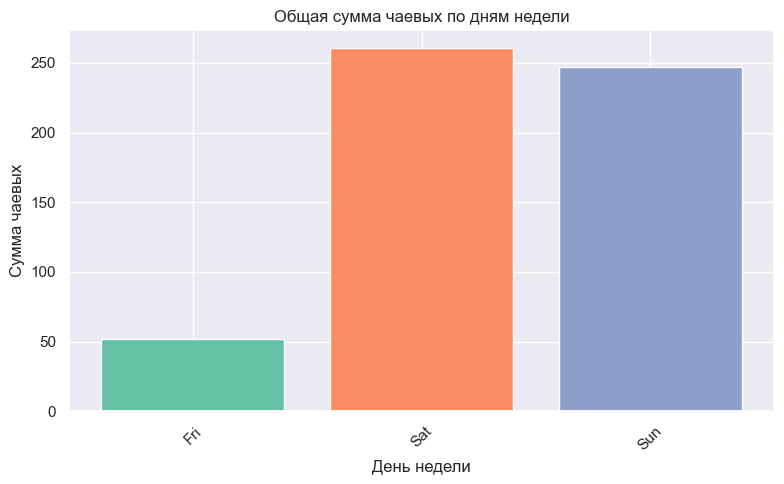

In [7]:
tip_sum = tips.groupby('day')['tip'].sum()

day_order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
tip_sum = tip_sum.reindex([d for d in day_order if d in tip_sum.index])

days = tip_sum.index
sums = tip_sum.values

colors = plt.cm.Set2.colors[:len(days)]

plt.figure(figsize=(8, 5))
plt.bar(days, sums, color=colors)

plt.xlabel('День недели')
plt.ylabel('Сумма чаевых')
plt.title('Общая сумма чаевых по дням недели')
plt.xticks(rotation=45)  # Наклон подписей

plt.tight_layout()
plt.show()

**Задание 3**. Загрузите набор данных `Video_Games_Sales_as_at_22_Dec_2016.csv`
1. Удалите из него все записи с пропусками и выведите размеры датафрейма (должно получиться 6825 записи)
2. Удалите лишние параметры. У вас должны остаться: 'Name', 'Platform', 'Year_of_Release', 'Genre', 'NA_Sales', 'EU_Sales', 'JP_Sales','Other_Sales', 'Global_Sales', 'Critic_Score', 'Critic_Count', 'User_Score', 'User_Count', 'Rating'
3. Скорректируйте формат данных. Параметр 'User_Score' должен иметь формат 'float64', 'Year_of_Release' — 'int64', 'User_Count' — 'int64', 'Critic_Count' — 'int64'
4. Выведите полученную таблицу
5. По полученной таблице постройте график продаж видео игр в различных странах в зависимости от года (см. рис. 2).

Рисунок 2 - Примерный результат

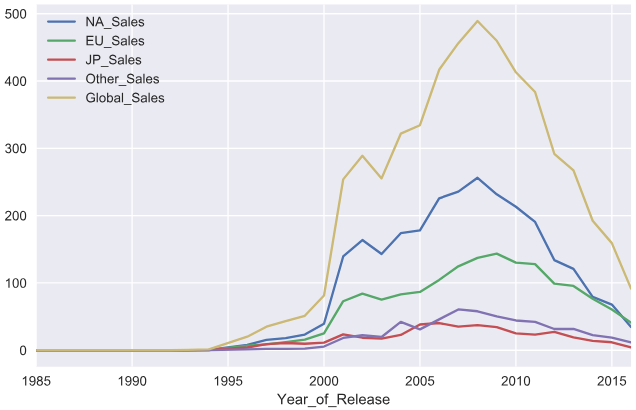

In [12]:
video_games = pd.read_csv('Video_Games_Sales_as_at_22_Dec_2016.csv', sep=',')
video_games = video_games.dropna()
print(video_games.shape)

(6825, 16)


In [14]:
video_games = video_games[['Name', 'Platform', 'Year_of_Release', 'Genre', 'NA_Sales', 'EU_Sales',
         'JP_Sales', 'Other_Sales', 'Global_Sales', 'Critic_Score',
         'Critic_Count', 'User_Score', 'User_Count', 'Rating']].copy()

video_games['User_Score'] = video_games['User_Score'].astype(float)
video_games['Year_of_Release'] = video_games['Year_of_Release'].astype(int)
video_games['User_Count'] = video_games['User_Count'].astype(int)
video_games['Critic_Count'] = video_games['Critic_Count'].astype(int)

video_games.head()

,Name,Platform,Year_of_Release,Genre,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Critic_Score,Critic_Count,User_Score,User_Count,Rating
0,Wii Sports,Wii,2006,Sports,41.36,28.96,3.77,8.45,82.53,76.0,51,8.0,322,E
2,Mario Kart Wii,Wii,2008,Racing,15.68,12.76,3.79,3.29,35.52,82.0,73,8.3,709,E
3,Wii Sports Resort,Wii,2009,Sports,15.61,10.93,3.28,2.95,32.77,80.0,73,8.0,192,E
6,New Super Mario Bros.,DS,2006,Platform,11.28,9.14,6.50,2.88,29.80,89.0,65,8.5,431,E
7,Wii Play,Wii,2006,Misc,13.96,9.18,2.93,2.84,28.92,58.0,41,6.6,129,E


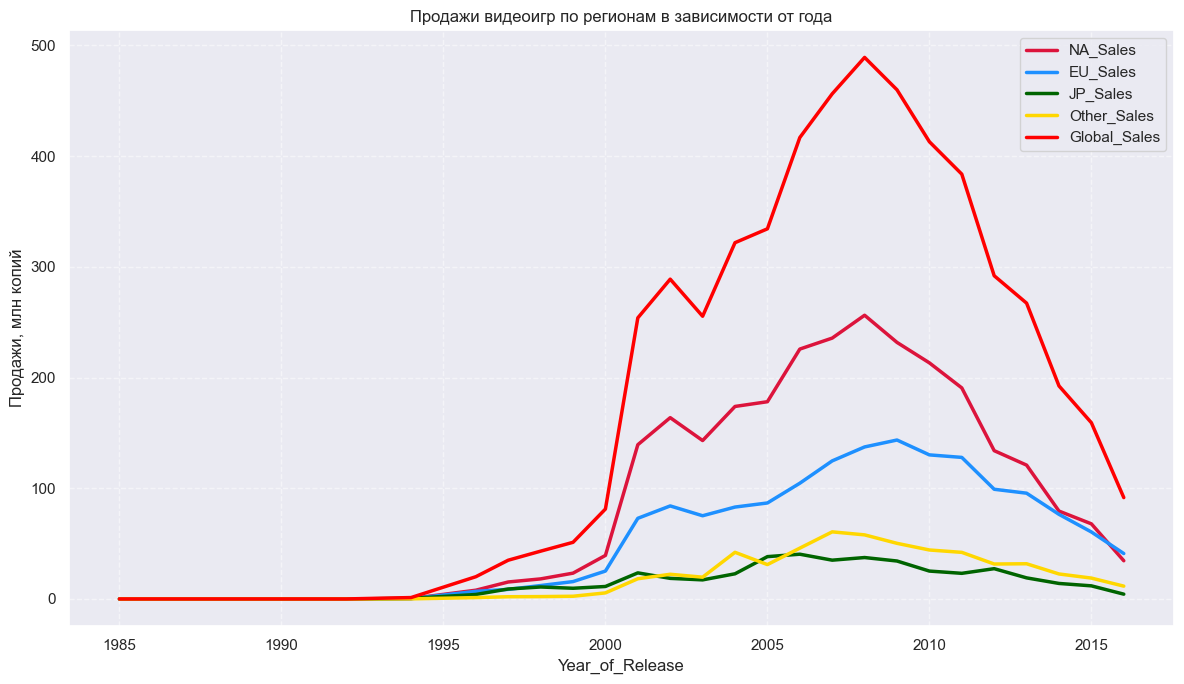

In [21]:
import matplotlib.pyplot as plt

sales_by_year = video_games.groupby('Year_of_Release')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']].sum()

plt.figure(figsize=(12, 7))
for region, color in zip(sales_by_year.columns, ['crimson', 'dodgerblue', 'darkgreen', 'gold', 'red']):
    plt.plot(sales_by_year.index, sales_by_year[region], label=region, linewidth=2.5, color=color)

plt.xlabel('Year_of_Release')
plt.ylabel('Продажи, млн копий')
plt.title('Продажи видеоигр по регионам в зависимости от года')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

**Задание 4**. С помощью библиотеки `seaborn` постройте распределение оценок критиков `Critic_Score` (рисунок 3) для датасета, загруженного в задании 3.

Рисунок 3 - Примерный результат  

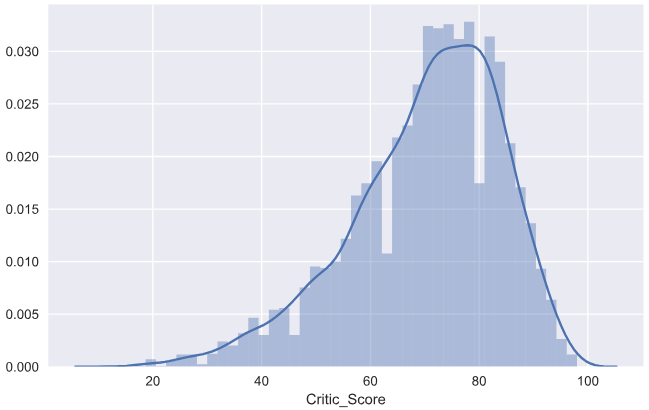

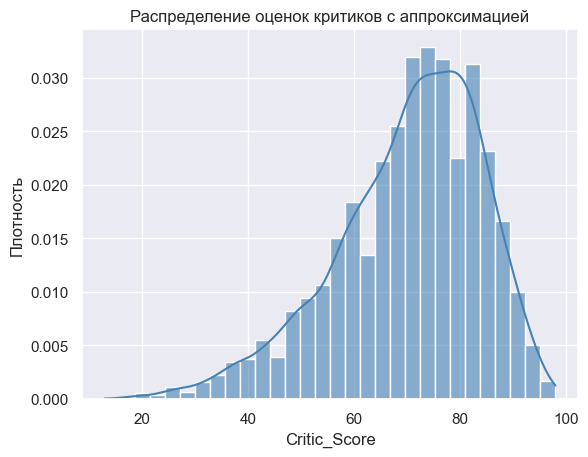

In [22]:
sns.histplot(video_games['Critic_Score'], kde=True, stat="density", bins=30, color="steelblue", alpha=0.6)
plt.xlabel('Critic_Score')
plt.ylabel('Плотность')
plt.title('Распределение оценок критиков с аппроксимацией')
plt.show()

**Задание 5**. Для того, чтобы подробнее посмотреть на взаимосвязь двух численных признаков, можно использовать __`joint_plot`__ — это гибрид `scatter plot` и `histogram` (отображаются также гистограммы распределений признаков). Продемонстрируйте, как связаны между собой оценка критиков `Critic_Score` и оценка пользователя `User_Score` для датасета из задания 3.

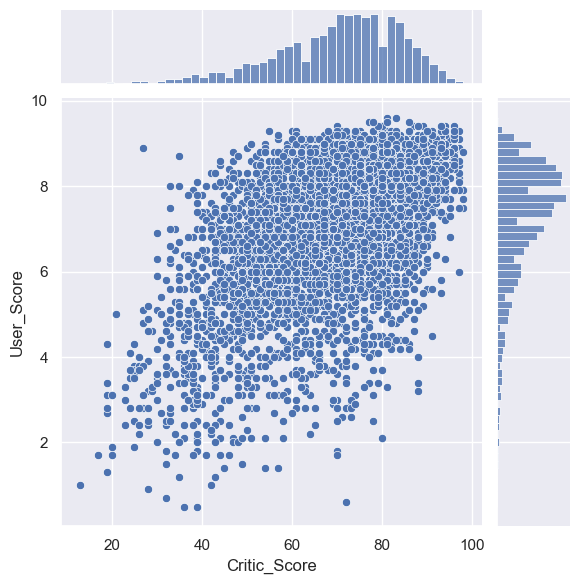

In [24]:
sns.jointplot(x = 'Critic_Score', y = 'User_Score', data = video_games)

**Задание 6.** Для датасета из задания 3 постройте pair plot для следующих признаков: 'Global_Sales', 'Critic_Score', 'Critic_Count', 'User_Score', 'User_Count'

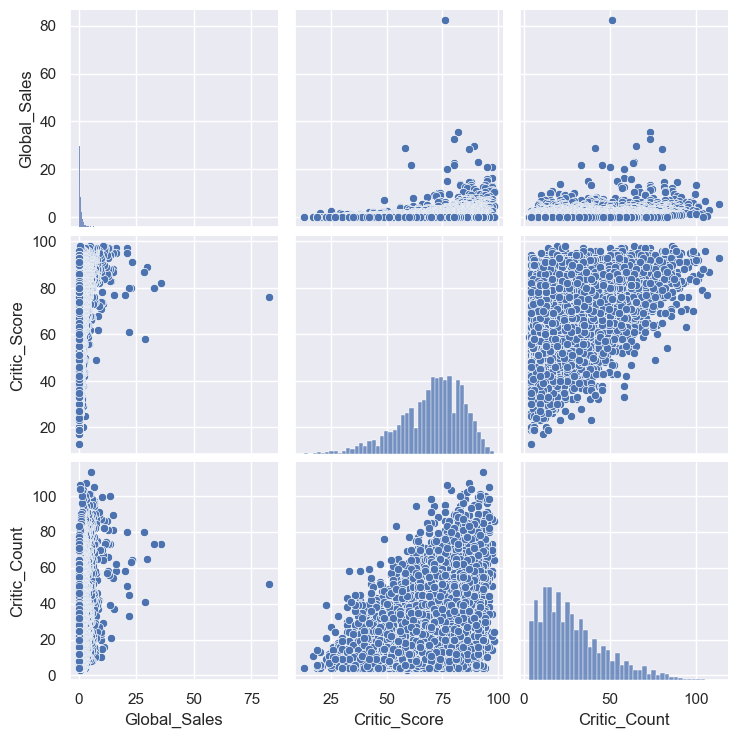

In [25]:
sns.pairplot(video_games[['Global_Sales', 'Critic_Score', 'Critic_Count']])
